# Notebook 04 — Clustering alternativo: features continuas + transformaciones + GMM

**Autora:** Victoria Di Liscia
**Programa:** Maestría en Explotación de Datos y Descubrimiento del Conocimiento — FCEN, UBA

## Motivación

El clustering del notebook 03 alcanzó un silhouette de 0.243 (K-Means k=3 sobre 21 features estandarizadas con StandardScaler). Este notebook explora si tres cambios metodológicos mejoran la calidad del agrupamiento:

1. **Reducir el espacio de features** a las 10 variables continuas (se descartan las 11 binarias de oferta de productos por baja varianza).
2. **Log-transformar** las variables más sesgadas (`liquidez`, `cartera_irregular`, `eficiencia`) antes de escalar.
3. **RobustScaler** (mediana e IQR) en vez de StandardScaler, menos sensible a outliers como Banco de Servicios Financieros.
4. **Gaussian Mixture Model (GMM)** como algoritmo principal — permite clusters elípticos y entrega probabilidades de pertenencia. K-Means queda como baseline.

El outlier Banco de Servicios Financieros se mantiene dentro del análisis para evaluar si las transformaciones nuevas lo absorben. La sección 11 repite GMM excluyéndolo como test de robustez.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED = ROOT / "data" / "processed"

SEED = 42
np.random.seed(SEED)
print(f"ROOT: {ROOT}")

ROOT: /Users/victoria/Documents/Maestria/tesis-perfiles-bancarios


## 2. Preparación de datos

Se replica el universo del notebook 03 para que la comparación sea limpia:
- 56 → 52 bancos (se excluyen Bank of China, JPMorgan, BNP Paribas, Cetelem).
- Promedio de los tres cortes (Dic-2023, Dic-2024, Dic-2025).
- **Solo las 10 features continuas** — no se incluyen las binarias de oferta.

In [2]:
panel = pd.read_csv(PROCESSED / "panel_ratios.csv")

# Mismas exclusiones que en el notebook 03
EXCLUIDOS = {131: "Bank of China", 165: "JPMorgan", 266: "BNP Paribas", 331: "Cetelem"}
panel = panel[~panel["codigo_entidad"].isin(EXCLUIDOS)].copy()

# Variables derivadas (idénticas al notebook 03)
panel["log_activo"] = np.log(panel["activo"])
panel["titulos_sobre_activo"] = panel["TÍTULOS PÚBLICOS Y PRIVADOS"].abs() / panel["activo"]
panel["patrimonio_sobre_activo"] = panel["patrimonio"].abs() / panel["activo"]
panel["log_activo_por_empleado"] = np.log(panel["activo_por_empleado"].clip(lower=1))

FEATURES = [
    "log_activo",
    "prestamos_sobre_activo",
    "titulos_sobre_activo",
    "depositos_sobre_activo",
    "patrimonio_sobre_activo",
    "roa",
    "liquidez",
    "eficiencia",
    "cartera_irregular",
    "log_activo_por_empleado",
]
META = ["codigo_entidad", "nombre_banco", "tipo_entidad"]

df = panel.groupby(META)[FEATURES].mean().reset_index()
print(f"Dataset: {df.shape[0]} bancos × {len(FEATURES)} features")

# Imputación por mediana
imputer = SimpleImputer(strategy="median")
df_imp = df.copy()
df_imp[FEATURES] = imputer.fit_transform(df[FEATURES])
print(f"Missings tras imputación: {df_imp[FEATURES].isnull().sum().sum()}")

Dataset: 52 bancos × 10 features
Missings tras imputación: 0


## 3. Transformaciones: log sobre variables sesgadas

Antes de escalar, aplicamos `log1p` sobre las tres variables más sesgadas:

- `liquidez`: distribución muy asimétrica (Banco de Servicios Financieros = 1622%).
- `cartera_irregular`: cola larga hacia bancos con mora alta.
- `eficiencia`: idem, valores altos en bancos chicos.

`log1p(x) = log(1+x)` es estable para valores cercanos a cero. Las tres variables son no-negativas en el panel.

In [3]:
LOG_VARS = ["liquidez", "cartera_irregular", "eficiencia"]

df_trans = df_imp.copy()
for v in LOG_VARS:
    df_trans[v] = np.log1p(df_trans[v])

# Comparación de skewness antes/después
print(f"{'Variable':<25} {'Skew antes':>12} {'Skew después':>14}")
print("-" * 53)
for v in LOG_VARS:
    skew_antes = df_imp[v].skew()
    skew_despues = df_trans[v].skew()
    print(f"{v:<25} {skew_antes:>12.2f} {skew_despues:>14.2f}")

Variable                    Skew antes   Skew después
-----------------------------------------------------
liquidez                          7.16           2.74
cartera_irregular                 2.18           0.37
eficiencia                        4.62           1.20


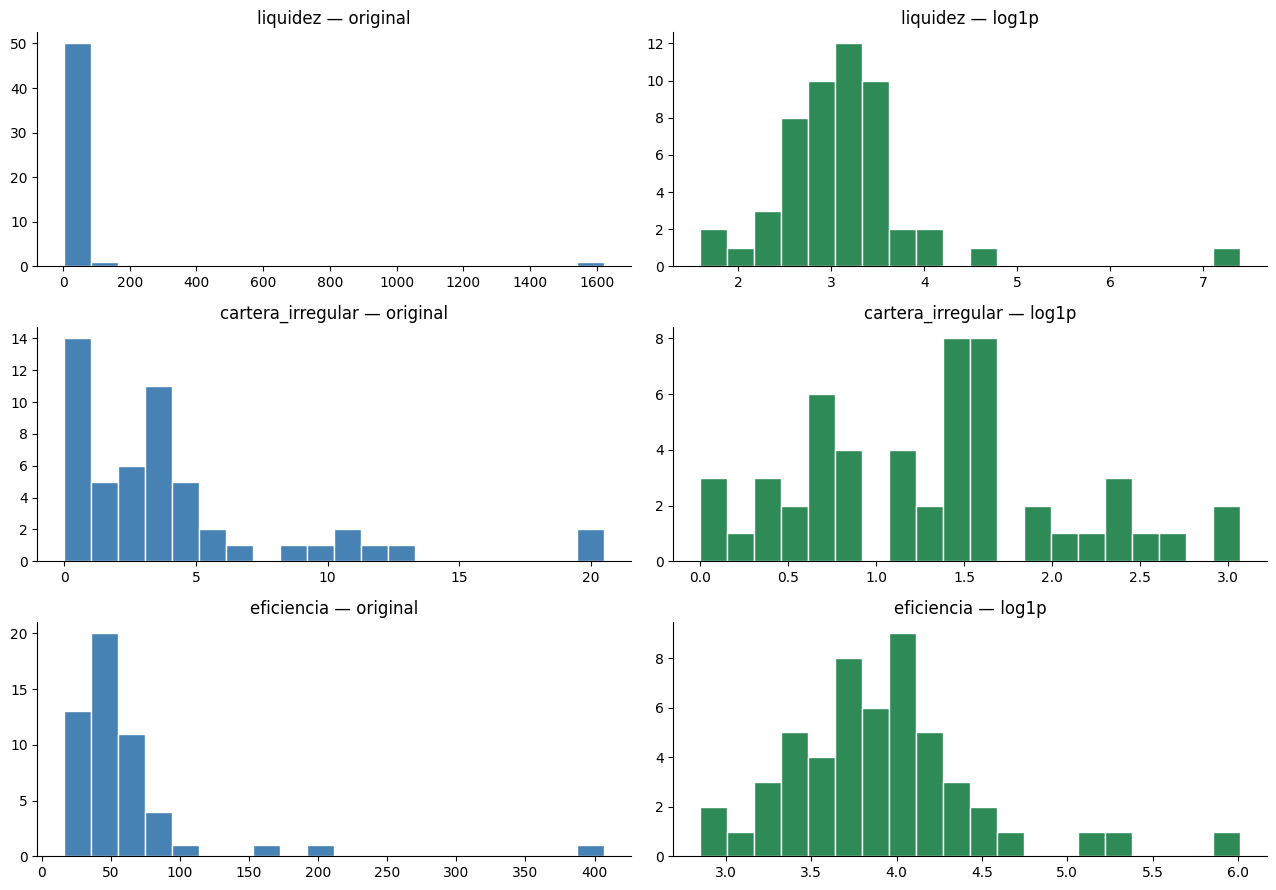

In [4]:
# Histogramas antes vs. después
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for i, v in enumerate(LOG_VARS):
    axes[i, 0].hist(df_imp[v], bins=20, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{v} — original")
    axes[i, 1].hist(df_trans[v], bins=20, color="seagreen", edgecolor="white")
    axes[i, 1].set_title(f"{v} — log1p")
plt.tight_layout()
plt.show()

## 4. Estandarización con RobustScaler

`RobustScaler` escala usando la mediana e IQR (Q3 - Q1) en vez de media y desvío. Es menos sensible a outliers: Banco de Servicios Financieros no va a "tirar" del centro de la distribución.

In [5]:
scaler = RobustScaler()
X = scaler.fit_transform(df_trans[FEATURES])
print(f"X shape: {X.shape}")
print(f"Mediana por feature (debería ser ~0): {np.median(X, axis=0).round(3)}")
print(f"IQR por feature (debería ser ~1):    {(np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)).round(3)}")

X shape: (52, 10)
Mediana por feature (debería ser ~0): [ 0.  0.  0. -0.  0.  0.  0. -0.  0.  0.]
IQR por feature (debería ser ~1):    [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. PCA exploratorio

### 5.1 Varianza explicada

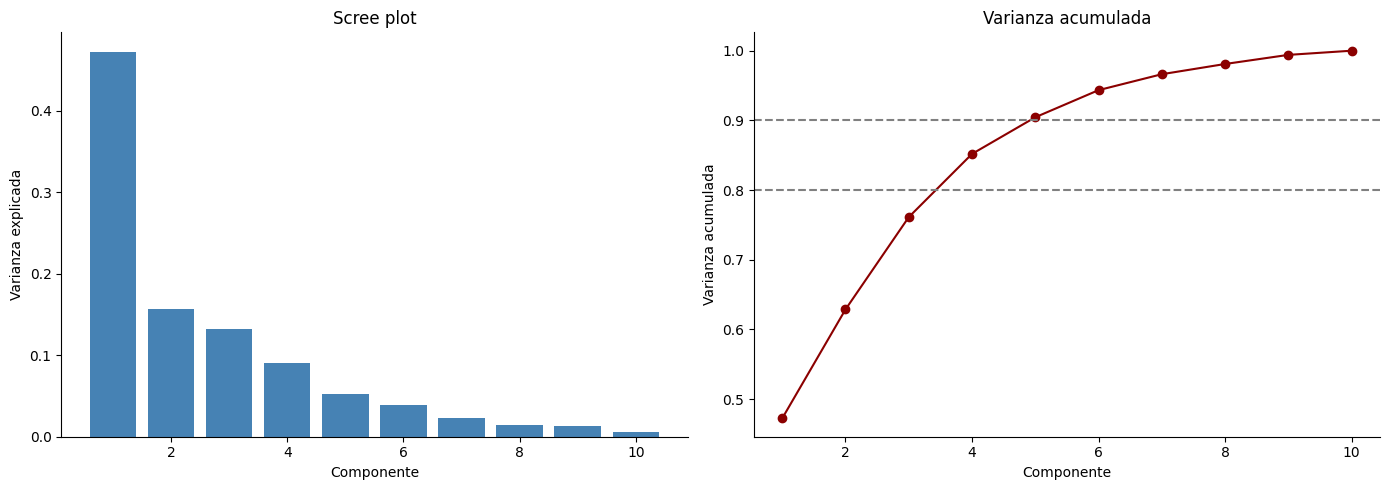

Componentes para 80 % de varianza: 4
Componentes para 90 % de varianza: 5

  PC1: 47.2 %  (acum. 47.2 %)
  PC2: 15.6 %  (acum. 62.9 %)
  PC3: 13.2 %  (acum. 76.1 %)
  PC4: 9.1 %  (acum. 85.2 %)
  PC5: 5.3 %  (acum. 90.4 %)
  PC6: 3.9 %  (acum. 94.3 %)


In [6]:
pca = PCA(n_components=min(X.shape))
pca.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color="steelblue")
axes[0].set_xlabel("Componente"); axes[0].set_ylabel("Varianza explicada"); axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), "o-", color="darkred")
axes[1].axhline(0.8, ls="--", color="gray"); axes[1].axhline(0.9, ls="--", color="gray")
axes[1].set_xlabel("Componente"); axes[1].set_ylabel("Varianza acumulada"); axes[1].set_title("Varianza acumulada")
plt.tight_layout(); plt.show()

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"Componentes para 80 % de varianza: {np.argmax(cumvar >= 0.8) + 1}")
print(f"Componentes para 90 % de varianza: {np.argmax(cumvar >= 0.9) + 1}")
print()
for i, v in enumerate(pca.explained_variance_ratio_[:6]):
    print(f"  PC{i+1}: {v*100:.1f} %  (acum. {cumvar[i]*100:.1f} %)")

### 5.2 Biplot PC1 vs PC2

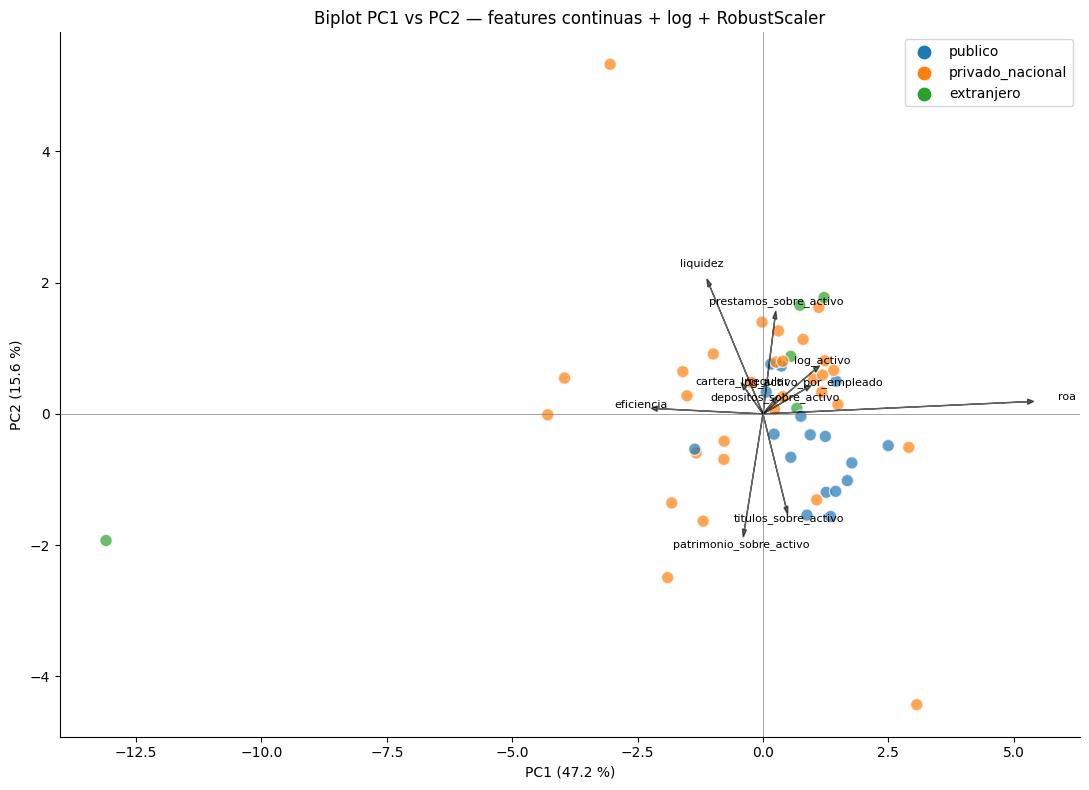

In [7]:
X_pca = pca.transform(X)

color_map = {"publico": "tab:blue", "privado_nacional": "tab:orange", "extranjero": "tab:green"}
colors = df_trans["tipo_entidad"].map(color_map)

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=80, alpha=0.7, edgecolor="white")
for tipo, col in color_map.items():
    mask = df_trans["tipo_entidad"] == tipo
    if mask.any():
        ax.scatter([], [], c=col, label=tipo, s=80)

# Loadings (flechas)
loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])
scale = 2.5
for i, var in enumerate(FEATURES):
    ax.arrow(0, 0, loadings[i, 0] * scale, loadings[i, 1] * scale, color="black", alpha=0.6, head_width=0.08)
    ax.text(loadings[i, 0] * scale * 1.15, loadings[i, 1] * scale * 1.15, var, fontsize=8, ha="center")

ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
ax.set_title("Biplot PC1 vs PC2 — features continuas + log + RobustScaler")
ax.legend(); plt.tight_layout(); plt.show()

### 5.3 Loadings

In [8]:
loadings_df = pd.DataFrame(
    pca.components_[:4].T,
    index=FEATURES,
    columns=[f"PC{i+1}" for i in range(4)]
)
print("Loadings de los primeros 4 componentes:\n")
print(loadings_df.round(3).to_string())

Loadings de los primeros 4 componentes:

                           PC1    PC2    PC3    PC4
log_activo               0.172  0.194 -0.070  0.347
prestamos_sobre_activo   0.040  0.422  0.101 -0.255
titulos_sobre_activo     0.076 -0.411  0.184  0.290
depositos_sobre_activo   0.034  0.054 -0.504  0.202
patrimonio_sobre_activo -0.062 -0.512  0.524 -0.126
roa                      0.882  0.054  0.081 -0.320
liquidez                -0.178  0.567  0.603  0.178
eficiencia              -0.353  0.023 -0.227 -0.382
cartera_irregular       -0.060  0.113  0.009 -0.399
log_activo_por_empleado  0.142  0.112 -0.001  0.484


## 6. K-Means k=3 — baseline comparativo

Antes de pasar a GMM, corremos K-Means k=3 sobre la nueva representación para medir cuánto contribuyen las **transformaciones por sí solas**, separadas del cambio de algoritmo.

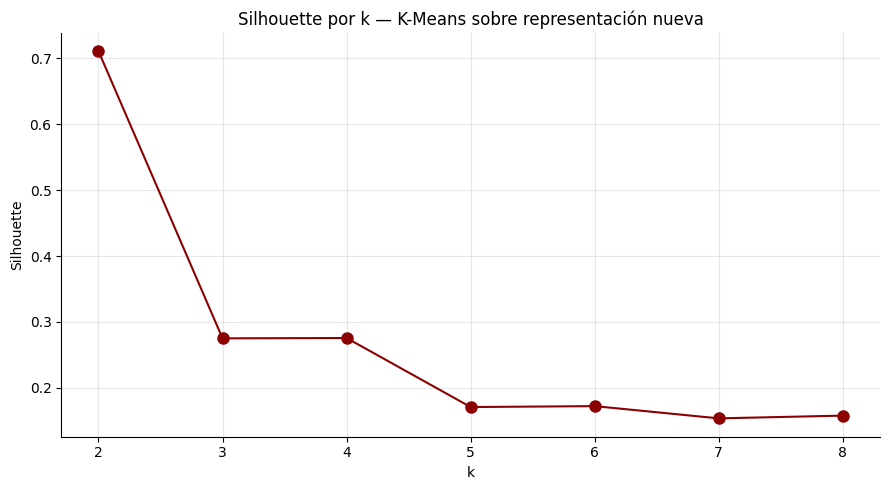

k óptimo : 2  (silhouette = 0.711)

  k=2: silhouette = 0.711 ← óptimo
  k=3: silhouette = 0.275
  k=4: silhouette = 0.276
  k=5: silhouette = 0.171
  k=6: silhouette = 0.172
  k=7: silhouette = 0.154
  k=8: silhouette = 0.158


In [9]:
# Selección de k vía silhouette
sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=100)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), "o-", color="darkred", markersize=8)
ax.set_xlabel("k"); ax.set_ylabel("Silhouette"); ax.set_title("Silhouette por k — K-Means sobre representación nueva")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"k óptimo : {max(sil_scores, key=sil_scores.get)}  (silhouette = {max(sil_scores.values()):.3f})\n")
for k, s in sil_scores.items():
    marker = " ← óptimo" if k == max(sil_scores, key=sil_scores.get) else ""
    print(f"  k={k}: silhouette = {s:.3f}{marker}")

In [10]:
km = KMeans(n_clusters=3, random_state=SEED, n_init=100)
df_trans["cluster_km04"] = km.fit_predict(X)
sil_km = silhouette_score(X, df_trans["cluster_km04"])

print(f"K-Means k=3 (representación nueva)")
print(f"Silhouette: {sil_km:.3f}")
print()
print("Distribución de clusters:")
print(df_trans["cluster_km04"].value_counts().sort_index())
print()
print("Composición por tipo de entidad:")
print(pd.crosstab(df_trans["cluster_km04"], df_trans["tipo_entidad"]))

K-Means k=3 (representación nueva)
Silhouette: 0.275

Distribución de clusters:
cluster_km04
0    37
1     1
2    14
Name: count, dtype: int64

Composición por tipo de entidad:
tipo_entidad  extranjero  privado_nacional  publico
cluster_km04                                       
0                      4                17       16
1                      1                 0        0
2                      0                13        1


## 7. Gaussian Mixture Model (modelo principal)

GMM modela cada cluster como una distribución gaussiana multivariada — a diferencia de K-Means, los clusters pueden ser elípticos (no esféricos) y con orientaciones distintas. Cada banco recibe una **probabilidad de pertenencia** a cada cluster, lo que permite identificar bancos "ambiguos" cerca de fronteras.

### 7.1 Selección de k vía BIC

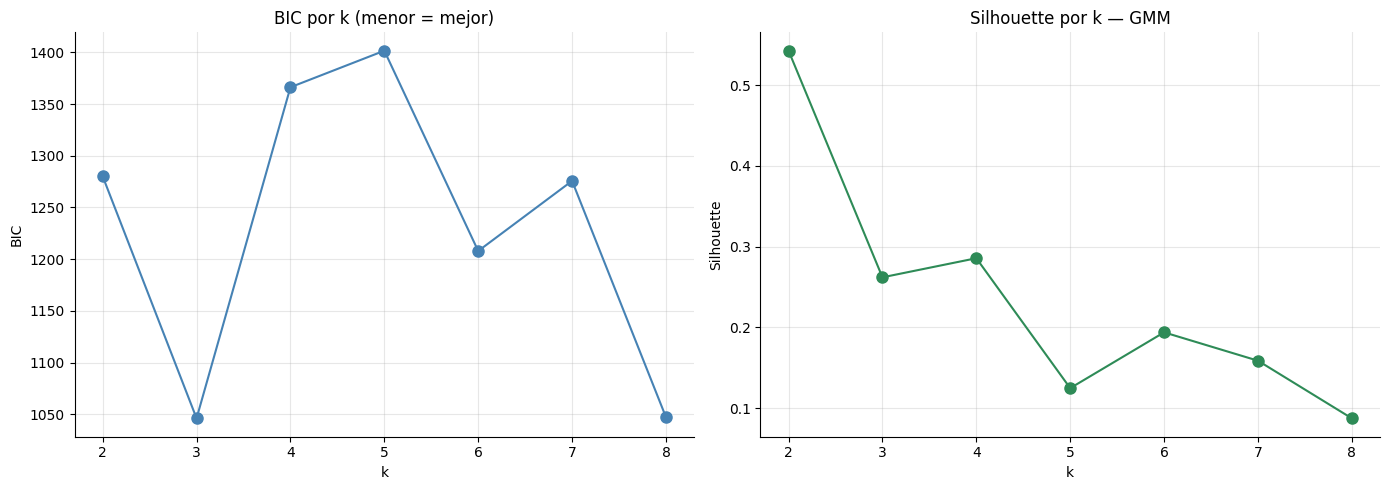

k con menor BIC      : 3  (BIC = 1046.0)
k con mejor silhouette: 2  (sil = 0.543)


In [11]:
bic_scores = {}
sil_gmm_scores = {}
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED, n_init=10)
    gmm.fit(X)
    bic_scores[k] = gmm.bic(X)
    labels = gmm.predict(X)
    sil_gmm_scores[k] = silhouette_score(X, labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(bic_scores.keys()), list(bic_scores.values()), "o-", color="steelblue", markersize=8)
axes[0].set_xlabel("k"); axes[0].set_ylabel("BIC"); axes[0].set_title("BIC por k (menor = mejor)")
axes[0].grid(alpha=0.3)

axes[1].plot(list(sil_gmm_scores.keys()), list(sil_gmm_scores.values()), "o-", color="seagreen", markersize=8)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette por k — GMM")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"k con menor BIC      : {min(bic_scores, key=bic_scores.get)}  (BIC = {min(bic_scores.values()):.1f})")
print(f"k con mejor silhouette: {max(sil_gmm_scores, key=sil_gmm_scores.get)}  (sil = {max(sil_gmm_scores.values()):.3f})")

### 7.2 Ajuste con k=3

In [12]:
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED, n_init=20)
gmm.fit(X)
df_trans["cluster_gmm"] = gmm.predict(X)
probs = gmm.predict_proba(X)
df_trans["cluster_gmm_prob"] = probs.max(axis=1)

sil_gmm = silhouette_score(X, df_trans["cluster_gmm"])

print(f"GMM k=3")
print(f"Silhouette: {sil_gmm:.3f}")
print(f"BIC       : {gmm.bic(X):.1f}")
print()
print("Distribución de clusters:")
print(df_trans["cluster_gmm"].value_counts().sort_index())
print()
print("Composición por tipo de entidad:")
print(pd.crosstab(df_trans["cluster_gmm"], df_trans["tipo_entidad"]))

GMM k=3
Silhouette: 0.262
BIC       : 1046.0

Distribución de clusters:
cluster_gmm
0     4
1    40
2     8
Name: count, dtype: int64

Composición por tipo de entidad:
tipo_entidad  extranjero  privado_nacional  publico
cluster_gmm                                        
0                      0                 4        0
1                      4                20       16
2                      1                 6        1


### 7.3 Probabilidades de pertenencia

In [13]:
# Bancos "ambiguos": probabilidad máxima < 0.7
ambiguos = df_trans[df_trans["cluster_gmm_prob"] < 0.7].sort_values("cluster_gmm_prob")
print(f"Bancos con pertenencia ambigua (p_max < 0.7): {len(ambiguos)}\n")
if len(ambiguos) > 0:
    cols_show = ["nombre_banco", "tipo_entidad", "cluster_gmm", "cluster_gmm_prob"]
    print(ambiguos[cols_show].to_string(index=False))

Bancos con pertenencia ambigua (p_max < 0.7): 0



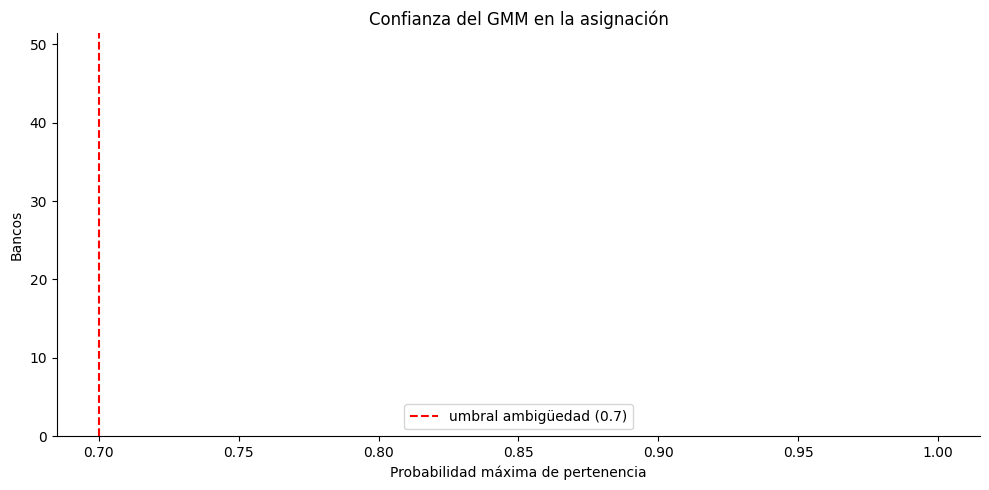

In [14]:
# Distribución de probabilidades máximas
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_trans["cluster_gmm_prob"], bins=25, color="steelblue", edgecolor="white")
ax.axvline(0.7, ls="--", color="red", label="umbral ambigüedad (0.7)")
ax.set_xlabel("Probabilidad máxima de pertenencia")
ax.set_ylabel("Bancos")
ax.set_title("Confianza del GMM en la asignación")
ax.legend(); plt.tight_layout(); plt.show()

### 7.4 Visualización en espacio PCA

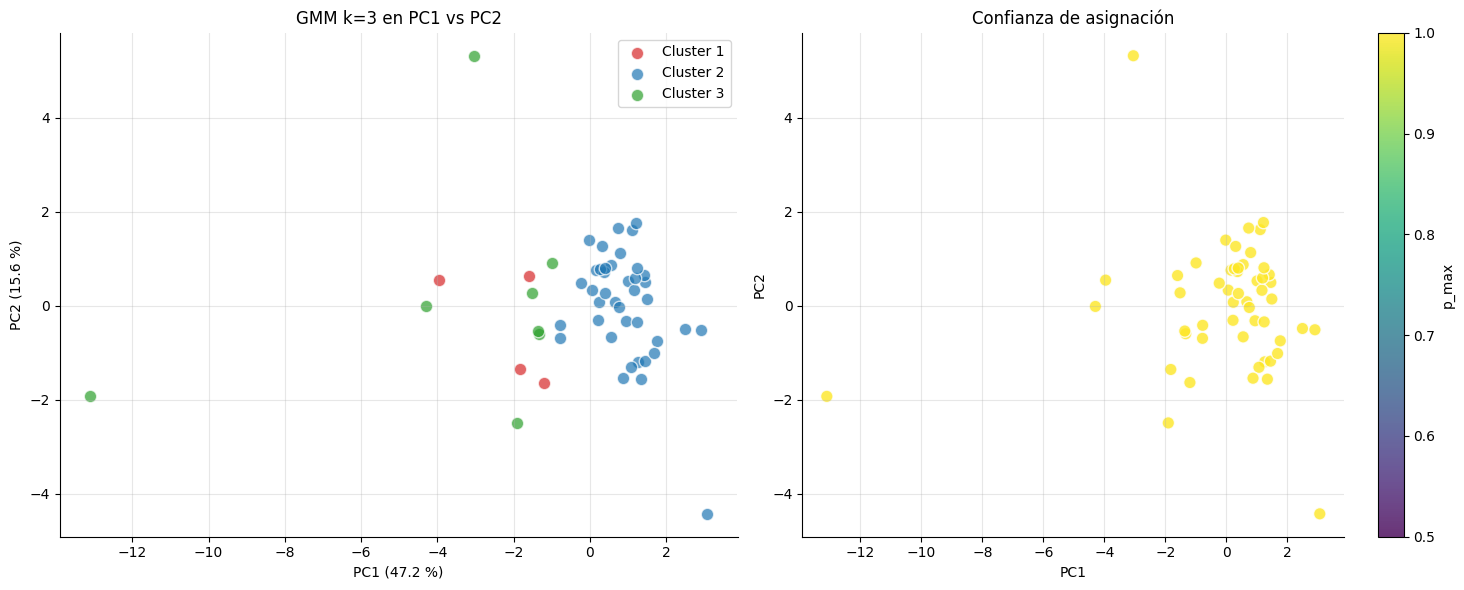

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = ["tab:red", "tab:blue", "tab:green"]

for k in range(3):
    mask = df_trans["cluster_gmm"] == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=palette[k], label=f"Cluster {k+1}", s=80, alpha=0.7, edgecolor="white")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
axes[0].set_title("GMM k=3 en PC1 vs PC2")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Colorear por probabilidad (gris = ambiguo)
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_trans["cluster_gmm_prob"], cmap="viridis", s=80, alpha=0.8, edgecolor="white", vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=axes[1], label="p_max")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].set_title("Confianza de asignación")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 7.5 Perfil de los clusters GMM

In [16]:
# Mediana por cluster sobre los valores ORIGINALES (sin log ni escalar)
perfil = df_imp.copy()
perfil["cluster_gmm"] = df_trans["cluster_gmm"].values
medianas = perfil.groupby("cluster_gmm")[FEATURES].median().T
medianas.columns = [f"Cluster {c+1}" for c in medianas.columns]
print("Mediana por cluster — variables originales (no transformadas):\n")
print(medianas.round(3).to_string())

Mediana por cluster — variables originales (no transformadas):

                         Cluster 1  Cluster 2  Cluster 3
log_activo                  18.598     20.672     18.150
prestamos_sobre_activo      20.249     30.216     25.387
titulos_sobre_activo         0.339      0.253      0.219
depositos_sobre_activo      77.552     64.977     47.492
patrimonio_sobre_activo      0.114      0.235      0.256
roa                         -4.465      2.763     -2.567
liquidez                    22.863     20.471     25.561
eficiencia                  71.323     39.343     86.171
cartera_irregular            6.963      2.245      9.415
log_activo_por_empleado     14.097     14.219     13.186


In [17]:
print("Bancos por cluster GMM:\n")
for c in sorted(df_trans["cluster_gmm"].unique()):
    sub = df_trans[df_trans["cluster_gmm"] == c].sort_values("cluster_gmm_prob", ascending=False)
    print(f"\n{'='*60}\nCLUSTER {c+1}  ({len(sub)} bancos)\n{'='*60}")
    for _, row in sub.iterrows():
        tag = {"publico": "PUB", "privado_nacional": "PRI", "extranjero": "EXT"}.get(row["tipo_entidad"], "???")
        marker = " *" if row["cluster_gmm_prob"] < 0.7 else ""
        print(f"  [{tag}]  {row['nombre_banco'][:38]:<38}  p={row['cluster_gmm_prob']:.2f}{marker}")

Bancos por cluster GMM:


CLUSTER 1  (4 bancos)
  [PRI]  BRUBANK S.A.U.                          p=1.00
  [PRI]  BANCO VOII S.A.                         p=1.00
  [PRI]  UALA BANK S.A.U.                        p=1.00
  [PRI]  BANCO DINO S.A.                         p=1.00

CLUSTER 2  (40 bancos)
  [PRI]  BANCO DE GALICIA Y BUENOS AIRES S.A     p=1.00
  [PUB]  BANCO DE LA NACION ARGENTINA            p=1.00
  [PRI]  BANCO ROELA S.A.                        p=1.00
  [PRI]  BANCO MARIVA S.A.                       p=1.00
  [PUB]  BANCO PROVINCIA DE TIERRA DEL FUEGO     p=1.00
  [PRI]  BANCO SAENZ S.A.                        p=1.00
  [PRI]  BANCO MACRO S.A.                        p=1.00
  [PRI]  BANCO COMAFI SOCIEDAD ANONIMA           p=1.00
  [PUB]  BANCO DE INVERSION Y COMERCIO EXTER     p=1.00
  [PRI]  BANCO PIANO S.A.                        p=1.00
  [PRI]  BANCO JULIO SOCIEDAD ANONIMA            p=1.00
  [PUB]  BANCO DE FORMOSA S.A.                   p=1.00
  [PRI]  BANCO CMF S.A.         

## 8. Comparación con el notebook 03

Cargamos la asignación de K-Means k=3 del notebook 03 para comparar:
- ¿Mejoró el silhouette?
- ¿Las particiones coinciden? (ARI / NMI)
- ¿Qué bancos cambiaron de grupo?

In [18]:
# Re-correr el K-Means del notebook 03 (StandardScaler, 21 features) para tener las etiquetas comparables
from sklearn.preprocessing import StandardScaler

FEATURES_03 = FEATURES + [
    "ofrece_hipoteca", "hipoteca_uva", "ofrece_personal", "ofrece_prendario",
    "ofrece_pfijo", "pfijo_uva", "ofrece_paquete", "paquete_tiene_premium",
    "ofrece_tarjeta", "tarjeta_tiene_premium", "caja_apertura_simplificada",
]

df_03 = panel.groupby(META)[FEATURES_03].mean().reset_index()
df_03_imp = df_03.copy()
df_03_imp[FEATURES_03] = SimpleImputer(strategy="median").fit_transform(df_03[FEATURES_03])
X_03 = StandardScaler().fit_transform(df_03_imp[FEATURES_03])

km_03 = KMeans(n_clusters=3, random_state=SEED, n_init=100)
df_03_imp["cluster_03"] = km_03.fit_predict(X_03)
sil_03 = silhouette_score(X_03, df_03_imp["cluster_03"])

# Merge sobre código de entidad
merged = df_trans.merge(df_03_imp[["codigo_entidad", "cluster_03"]], on="codigo_entidad")

print(f"{'Método':<55} {'Silhouette':>12}")
print("-" * 68)
print(f"{'K-Means k=3 — notebook 03 (21 feat + StandardScaler)':<55} {sil_03:>12.3f}")
print(f"{'K-Means k=3 — notebook 04 (10 feat + log + Robust)':<55} {sil_km:>12.3f}")
print(f"{'GMM k=3      — notebook 04 (10 feat + log + Robust)':<55} {sil_gmm:>12.3f}")

Método                                                    Silhouette
--------------------------------------------------------------------
K-Means k=3 — notebook 03 (21 feat + StandardScaler)           0.243
K-Means k=3 — notebook 04 (10 feat + log + Robust)             0.275
GMM k=3      — notebook 04 (10 feat + log + Robust)            0.262


In [19]:
print("Tabla de contingencia: K-Means 03 vs GMM 04\n")
ct = pd.crosstab(merged["cluster_03"], merged["cluster_gmm"], rownames=["KM-03"], colnames=["GMM-04"])
print(ct)

ari_gmm_vs_03 = adjusted_rand_score(merged["cluster_03"], merged["cluster_gmm"])
nmi_gmm_vs_03 = normalized_mutual_info_score(merged["cluster_03"], merged["cluster_gmm"])
print(f"\nARI (GMM-04 vs KM-03): {ari_gmm_vs_03:.3f}")
print(f"NMI (GMM-04 vs KM-03): {nmi_gmm_vs_03:.3f}")

Tabla de contingencia: K-Means 03 vs GMM 04

GMM-04  0   1  2
KM-03           
0       1  10  0
1       2  26  1
2       1   4  7

ARI (GMM-04 vs KM-03): 0.215
NMI (GMM-04 vs KM-03): 0.233


In [20]:
print("Tabla de contingencia: K-Means 03 vs K-Means 04\n")
ct_km = pd.crosstab(merged["cluster_03"], merged["cluster_km04"], rownames=["KM-03"], colnames=["KM-04"])
print(ct_km)

ari_km_vs_03 = adjusted_rand_score(merged["cluster_03"], merged["cluster_km04"])
nmi_km_vs_03 = normalized_mutual_info_score(merged["cluster_03"], merged["cluster_km04"])
print(f"\nARI (KM-04 vs KM-03): {ari_km_vs_03:.3f}")
print(f"NMI (KM-04 vs KM-03): {nmi_km_vs_03:.3f}")

Tabla de contingencia: K-Means 03 vs K-Means 04

KM-04   0  1  2
KM-03          
0       7  0  4
1      26  0  3
2       4  1  7

ARI (KM-04 vs KM-03): 0.238
NMI (KM-04 vs KM-03): 0.171


### Bancos que cambiaron de cluster

In [21]:
# Para que la comparación sea legible, alineo etiquetas: para cada cluster GMM, le asigno el "mejor match" en KM-03
ct_aligned = pd.crosstab(merged["cluster_gmm"], merged["cluster_03"])
gmm_to_03 = ct_aligned.idxmax(axis=1).to_dict()
merged["gmm_realigned"] = merged["cluster_gmm"].map(gmm_to_03)

cambios = merged[merged["gmm_realigned"] != merged["cluster_03"]]
print(f"Bancos que cambian de cluster entre KM-03 y GMM-04 (después de realinear etiquetas): {len(cambios)}\n")
cols = ["nombre_banco", "tipo_entidad", "cluster_03", "cluster_gmm", "cluster_gmm_prob"]
print(cambios[cols].sort_values("cluster_gmm_prob").to_string(index=False))

Bancos que cambian de cluster entre KM-03 y GMM-04 (después de realinear etiquetas): 17

                       nombre_banco     tipo_entidad  cluster_03  cluster_gmm  cluster_gmm_prob
                 BANCO DEL SOL S.A. privado_nacional           1            2               1.0
                      CITIBANK N.A.       extranjero           0            1               1.0
BACS BANCO DE CREDITO Y SECURITIZAC privado_nacional           0            1               1.0
 BANCO DE SERVICIOS Y TRANSACCIONES privado_nacional           0            1               1.0
  BANCO DE SANTIAGO DEL ESTERO S.A.          publico           2            1               1.0
                     BANCO CMF S.A. privado_nacional           0            1               1.0
                    BANCO VOII S.A. privado_nacional           0            0               1.0
                   UALA BANK S.A.U. privado_nacional           2            0               1.0
       BANCO JULIO SOCIEDAD ANONIMA privado_nac

## 9. Conclusiones del notebook 04

*Esta sección se completa con los números reales una vez ejecutado el notebook.*

**Métricas comparativas**:
- K-Means 03 (21 feat + StandardScaler): silhouette ≈ 0.243
- K-Means 04 (10 feat + log + RobustScaler): silhouette ≈ {pendiente}
- GMM 04 (10 feat + log + RobustScaler): silhouette ≈ {pendiente}

**Preguntas a responder con los resultados**:

1. **¿Las transformaciones por sí solas mejoran K-Means?** Comparar KM-03 vs KM-04.
2. **¿GMM aporta sobre K-Means en el mismo espacio?** Comparar KM-04 vs GMM-04.
3. **¿Las particiones son consistentes con el notebook 03?** Si ARI alto → la estructura es robusta al cambio metodológico. Si ARI bajo → la elección de features y escala estaba forzando una partición específica.
4. **¿Qué bancos siguen ambiguos en GMM?** Los que tengan probabilidad < 0.7 son candidatos a estar "entre perfiles".
5. **¿RobustScaler absorbió el outlier?** Inspeccionar a Banco de Servicios Financieros: ¿quedó en un cluster con otros o aislado?

## 11. Robustez: GMM sin el outlier

Replicamos el GMM k=3 excluyendo a Banco de Servicios Financieros. Si las transformaciones del notebook lo absorbieron correctamente, la partición debería ser similar a la de la sección 7 (ARI alto). Si no, esto da una versión "limpia" para comparar contra la sección 4.6 del notebook 03.

In [22]:
OUTLIER_NOMBRE = "BANCO DE SERVICIOS FINANCIEROS"
mask_no_out = ~df_trans["nombre_banco"].str.contains(OUTLIER_NOMBRE, case=False, na=False)
df_no_out = df_trans[mask_no_out].copy().reset_index(drop=True)

# Re-ajustamos el scaler y el log sobre el panel sin outlier
df_orig_no_out = df_imp[mask_no_out].copy().reset_index(drop=True)
df_trans_no_out = df_orig_no_out.copy()
for v in LOG_VARS:
    df_trans_no_out[v] = np.log1p(df_trans_no_out[v])

scaler_no_out = RobustScaler()
X_no_out = scaler_no_out.fit_transform(df_trans_no_out[FEATURES])

print(f"Bancos sin outlier: {len(df_no_out)}")
print(f"Excluido          : {df_trans[~mask_no_out]['nombre_banco'].iloc[0]}")

Bancos sin outlier: 51
Excluido          : BANCO DE SERVICIOS FINANCIEROS S.A.


In [23]:
gmm_no_out = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED, n_init=20)
gmm_no_out.fit(X_no_out)
df_no_out["cluster_gmm_no_out"] = gmm_no_out.predict(X_no_out)
df_no_out["cluster_gmm_no_out_prob"] = gmm_no_out.predict_proba(X_no_out).max(axis=1)

sil_no_out = silhouette_score(X_no_out, df_no_out["cluster_gmm_no_out"])
print(f"GMM k=3 sin outlier")
print(f"Silhouette: {sil_no_out:.3f}  (vs {sil_gmm:.3f} con outlier)")
print()
print("Distribución de clusters:")
print(df_no_out["cluster_gmm_no_out"].value_counts().sort_index())

GMM k=3 sin outlier
Silhouette: 0.258  (vs 0.262 con outlier)

Distribución de clusters:
cluster_gmm_no_out
0    42
1     3
2     6
Name: count, dtype: int64


In [24]:
# Comparación con outlier vs sin outlier
df_comp = df_trans[mask_no_out].copy().reset_index(drop=True)
df_comp["cluster_gmm_no_out"] = df_no_out["cluster_gmm_no_out"].values

ct_robust = pd.crosstab(df_comp["cluster_gmm"], df_comp["cluster_gmm_no_out"], rownames=["CON-out"], colnames=["SIN-out"])
print("Tabla de contingencia: GMM con vs sin outlier\n")
print(ct_robust)

ari_robust = adjusted_rand_score(df_comp["cluster_gmm"], df_comp["cluster_gmm_no_out"])
print(f"\nAdjusted Rand Index: {ari_robust:.3f}")
print("(cerca de 1 = la partición es robusta al outlier)")

Tabla de contingencia: GMM con vs sin outlier

SIN-out   0  1  2
CON-out          
0         2  1  1
1        36  0  4
2         4  2  1

Adjusted Rand Index: 0.306
(cerca de 1 = la partición es robusta al outlier)


In [25]:
# Perfil mediano sin outlier
perfil_no_out = df_imp[mask_no_out].copy().reset_index(drop=True)
perfil_no_out["cluster_gmm_no_out"] = df_no_out["cluster_gmm_no_out"].values
medianas_no_out = perfil_no_out.groupby("cluster_gmm_no_out")[FEATURES].median().T
medianas_no_out.columns = [f"Cluster {c+1}" for c in medianas_no_out.columns]
print("Mediana por cluster — GMM sin outlier (variables originales):\n")
print(medianas_no_out.round(3).to_string())

Mediana por cluster — GMM sin outlier (variables originales):

                         Cluster 1  Cluster 2  Cluster 3
log_activo                  20.207     17.064     19.564
prestamos_sobre_activo      30.894     20.915     19.290
titulos_sobre_activo         0.242      0.266      0.492
depositos_sobre_activo      66.012     67.124     44.826
patrimonio_sobre_activo      0.224      0.225      0.389
roa                          2.294    -11.897      2.230
liquidez                    20.832     27.631     18.453
eficiencia                  44.748    193.761     31.056
cartera_irregular            2.855      8.497      2.617
log_activo_por_empleado     14.081     12.720     14.059
